# Experiment 01 — Within-Model Gradient Distance Correlation

This notebook evaluates how the number of random hyperplanes $r$ in LSHFed-style random-hyperplane hashing affects the correspondence between **Euclidean distance** and **Hamming distance** for gradients generated from the same model state.

The experiment uses CIFAR-10, a ResNet9-style model, 100 stochastic gradient samples, and all 4,950 pairwise gradient comparisons. Smaller $r$ values use prefixes of one fixed projection bank so that changing $r$ is the only projection-bank difference.

> Scope. This is a within-model gradient-similarity experiment. It does not reproduce the complete LSHFed verifier workflow.


In [ ]:
from pathlib import Path
import os
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from scipy.stats import pearsonr, spearmanr

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IN_COLAB = "google.colab" in sys.modules

# Portable, relative paths. These work in Colab, Jupyter, or a local clone.
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Running in Colab:", IN_COLAB)
print("Working directory:", BASE_DIR.resolve())
print("Device:", DEVICE)
print("PyTorch:", torch.__version__)


## 1. Environment and reproducibility setup

The notebook is self-contained, meaning that it does not need cloning the original LSHFed repository or mounting Google Drive. Public data are downloaded automatically, and generated outputs are written to relative `data/` and `results/` directories.


In [ ]:
# Reproducibility settings used by this experiment.
print("Seed:", SEED)
print("Data directory:", DATA_DIR.resolve())
print("Results directory:", RESULTS_DIR.resolve())


## 2. Experiment configuration

We evaluate multiple values of $r$ while reusing prefixes of a single fixed bank of random hyperplanes.


In [ ]:
R_VALUES = [1, 2, 4, 5, 8, 16, 32, 64, 128, 256]

MAX_R = max(R_VALUES)

print("r values:", R_VALUES)

r values: [1, 2, 4, 5, 8, 16, 32, 64, 128, 256]


## 3. LSHFed-style hashing utilities

The following functions reproduce the flattening, random-hyperplane projection, sign thresholding, and Hamming-distance operations as used by the reference LSHFed implementation. Random vectors are supplied explicitly so that the same projection bank can be reused across all values of $r$.


In [ ]:
def flatten_to_2d(t):
    """
    Faithful reproduction of LSHFed's _flatten_to_2d().
    """
    if t.dim() == 1:
        return t.view(-1, 1)
    elif t.dim() == 2:
        return t
    else:
        return t.view(t.size(0), -1)


def lsh_hash(gradient, random_vectors):
    """
    Faithful reproduction of LSHFed's LSH() operation,
    except that random_vectors are explicitly supplied.

    random_vectors shape:
        [r, number_of_rows]
    """

    grad_2d = flatten_to_2d(
        gradient.detach().to("cpu")
    )

    random_vectors = random_vectors.to(
        device="cpu",
        dtype=grad_2d.dtype
    )

    if random_vectors.shape[1] != grad_2d.shape[0]:
        raise ValueError(
            f"Projection dimension mismatch: "
            f"random vectors expect {random_vectors.shape[1]} rows, "
            f"but gradient has {grad_2d.shape[0]} rows."
        )

    hashes = []

    for rand_vec in random_vectors:
        dots = torch.mv(grad_2d.t(), rand_vec)

        # Exactly the repository's sign convention:
        # dots > 0 -> 1
        # otherwise -> 0
        hashes.append((dots > 0).int())

    return torch.stack(hashes)


def hamming_distance(hash1, hash2):
    """
    Raw Hamming distance.
    """
    if hash1.shape != hash2.shape:
        raise ValueError(
            f"Hash shapes differ: {hash1.shape} vs {hash2.shape}"
        )

    return torch.ne(hash1, hash2).sum().item()


def normalized_hamming_distance(hash1, hash2):
    """
    Hamming distance normalized by total number of hash bits.
    """
    raw = hamming_distance(hash1, hash2)
    return raw / hash1.numel()

## 4. Fixed projection bank

One bank containing `MAX_R` random hyperplanes is generated once. For an experiment with a smaller $r$, the first $r$ vectors are used.


In [ ]:
def generate_projection_bank(num_rows, max_r=MAX_R, seed=SEED):
    """
    Generate one fixed bank of random hyperplanes.

    Shape:
        [max_r, num_rows]

    The first r rows are used for an experiment with r hyperplanes.
    """

    generator = torch.Generator(device="cpu")
    generator.manual_seed(seed)

    return torch.randn(
        max_r,
        num_rows,
        generator=generator,
        dtype=torch.float32
    )


def get_projection_vectors(projection_bank, r):
    if r > projection_bank.shape[0]:
        raise ValueError("Requested r exceeds projection bank size.")

    return projection_bank[:r]

## 5. Sanity check

A small synthetic example verifies the expected hash shape and sign-thresholding behavior before running the full experiment.


In [ ]:
# Generate a test gradient
torch.manual_seed(123)

test_gradient = torch.randn(64, 32)

# Generate exactly 5 random vectors
torch.manual_seed(999)

test_random_vectors = torch.randn(
    5,
    flatten_to_2d(test_gradient).shape[0]
)

# Our implementation
our_hash = lsh_hash(
    test_gradient,
    test_random_vectors
)

print("Hash shape:", our_hash.shape)
print("First hash:", our_hash[0, :10])

Hash shape: torch.Size([5, 32])
First hash: tensor([0, 0, 0, 0, 1, 1, 0, 1, 0, 1], dtype=torch.int32)


## 6. Model definition

The experiment uses the CIFAR-10 ResNet9-style architecture used in the original experimental setup.


In [ ]:
import torch.nn as nn


def conv_block(in_channels, out_channels, pool=False):
    layers = [
        nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        ),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    ]

    if pool:
        layers.append(nn.MaxPool2d(2))

    return nn.Sequential(*layers)


class CIFARResNet9(nn.Module):

    def __init__(self, in_channels=3, num_classes=10):
        super().__init__()

        self.conv1 = conv_block(in_channels, 64)
        self.conv2 = conv_block(64, 128, pool=True)

        self.res1 = nn.Sequential(
            conv_block(128, 128),
            conv_block(128, 128)
        )

        self.conv3 = conv_block(128, 256, pool=True)
        self.conv4 = conv_block(256, 512, pool=True)

        self.res2 = nn.Sequential(
            conv_block(512, 512),
            conv_block(512, 512)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveMaxPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        out = self.conv1(x)
        out = self.conv2(out)

        out = self.res1(out) + out

        out = self.conv3(out)
        out = self.conv4(out)

        out = self.res2(out) + out

        return self.classifier(out)


model = CIFARResNet9().to(DEVICE)

print(
    "Total parameters:",
    sum(p.numel() for p in model.parameters())
)

Total parameters: 6575370


## 7. Load CIFAR-10

CIFAR-10 is downloaded automatically. No manual downloading required.


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

train_dataset = datasets.CIFAR10(
    root=str(DATA_DIR),
    train=True,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))

100%|██████████| 170M/170M [21:16<00:00, 134kB/s]


Training samples: 50000


## 8. Collect stochastic gradients from one fixed model state

For each sample, a fresh local model is restored to the same initial state, one mini-batch is processed, and the gradient of `res2[0][0].weight` is stored. Thus, variation across gradients comes from the sampled mini-batches rather than from model-state drift.


In [ ]:
import copy

BATCH_SIZE = 16
NUM_GRADIENT_SAMPLES = 100

loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

base_model = CIFARResNet9().to(DEVICE)
base_state = copy.deepcopy(base_model.state_dict())

criterion = nn.CrossEntropyLoss()

gradient_samples = []

data_iter = iter(loader)

for sample_idx in range(NUM_GRADIENT_SAMPLES):

    try:
        images, labels = next(data_iter)
    except StopIteration:
        data_iter = iter(loader)
        images, labels = next(data_iter)

    local_model = CIFARResNet9().to(DEVICE)
    local_model.load_state_dict(base_state)

    optimizer = torch.optim.SGD(
        local_model.parameters(),
        lr=0.01
    )

    images = images.to(DEVICE)
    labels = labels.to(DEVICE)

    optimizer.zero_grad()

    outputs = local_model(images)
    loss = criterion(outputs, labels)

    loss.backward()

    # We collect exactly the layer used in the repository's
    # README example.
    grad = (
        local_model.res2[0][0].weight.grad
        .detach()
        .cpu()
        .clone()
    )

    gradient_samples.append(grad)

    del local_model
    del images
    del labels
    del outputs
    del loss

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if (sample_idx + 1) % 10 == 0:
        print(
            f"Collected {sample_idx + 1}/"
            f"{NUM_GRADIENT_SAMPLES}"
        )

print("Gradient shape:", gradient_samples[0].shape)

Collected 10/100
Collected 20/100
Collected 30/100
Collected 40/100
Collected 50/100
Collected 60/100
Collected 70/100
Collected 80/100
Collected 90/100
Collected 100/100
Gradient shape: torch.Size([512, 512, 3, 3])


## 9. Check gradient memory usage

This reports the approximate memory required to hold all collected gradients in RAM.


In [ ]:
total_elements = sum(
    g.numel()
    for g in gradient_samples
)

total_mb = (
    total_elements *
    gradient_samples[0].element_size()
    / (1024 ** 2)
)

print(f"Stored gradient memory: {total_mb:.2f} MB")

Stored gradient memory: 900.00 MB


## 10. Build the projection bank for the selected gradient layer

The collected convolutional gradient is flattened to be fed into the hashing function, and the fixed bank of random hyperplanes is generated such that each hyperplane size equals the number of rows of the base gradient.

The number of bits in the hashed bit string, on the other hand, equals the number of columns of the base gradient multiplied by r.


In [ ]:
sample_shape = gradient_samples[0].shape

gradient_2d = flatten_to_2d(
    gradient_samples[0]
)

num_rows = gradient_2d.shape[0]

print("Original shape:", sample_shape)
print("LSH 2D shape:", gradient_2d.shape)
print("Projection dimension:", num_rows)

projection_bank = generate_projection_bank(
    num_rows=num_rows,
    max_r=MAX_R,
    seed=SEED
)

print("Projection bank shape:", projection_bank.shape)

Original shape: torch.Size([512, 512, 3, 3])
LSH 2D shape: torch.Size([512, 4608])
Projection dimension: 512
Projection bank shape: torch.Size([256, 512])


## 11. Compute Euclidean distances

Full-gradient Euclidean distance is computed for every unique pair of the 100 collected gradients.


In [ ]:
euclidean_distances = []

num_samples = len(gradient_samples)

for i in range(num_samples):
    for j in range(i + 1, num_samples):

        g1 = gradient_samples[i].float()
        g2 = gradient_samples[j].float()

        distance = torch.norm(
            g1 - g2,
            p=2
        ).item()

        euclidean_distances.append(distance)

euclidean_distances = np.array(
    euclidean_distances,
    dtype=np.float64
)

print(
    "Number of gradient pairs:",
    len(euclidean_distances)
)

Number of gradient pairs: 4950


## 12. Compute LSH Hamming distances for each $r$

Each gradient is hashed with every tested value of $r$. Both raw and normalized Hamming distances are recorded for all gradient pairs.


In [ ]:
hashes_by_r = {}
hamming_results = {}

for r in R_VALUES:

    projections = get_projection_vectors(
        projection_bank,
        r
    )

    hashes = []

    for gradient in gradient_samples:
        hashes.append(
            lsh_hash(
                gradient,
                projections
            )
        )

    hashes_by_r[r] = hashes

    raw_distances = []
    normalized_distances = []

    pair_index = 0

    for i in range(num_samples):
        for j in range(i + 1, num_samples):

            h1 = hashes[i]
            h2 = hashes[j]

            raw = hamming_distance(h1, h2)
            normalized = normalized_hamming_distance(
                h1,
                h2
            )

            raw_distances.append(raw)
            normalized_distances.append(normalized)

            pair_index += 1

    hamming_results[r] = {
        "raw": np.array(raw_distances),
        "normalized": np.array(normalized_distances)
    }

    print(
        f"r={r:3d} | "
        f"hash shape={hashes[0].shape}"
    )

r=  1 | hash shape=torch.Size([1, 4608])
r=  2 | hash shape=torch.Size([2, 4608])
r=  4 | hash shape=torch.Size([4, 4608])
r=  5 | hash shape=torch.Size([5, 4608])
r=  8 | hash shape=torch.Size([8, 4608])
r= 16 | hash shape=torch.Size([16, 4608])
r= 32 | hash shape=torch.Size([32, 4608])
r= 64 | hash shape=torch.Size([64, 4608])
r=128 | hash shape=torch.Size([128, 4608])
r=256 | hash shape=torch.Size([256, 4608])


## 13. Correlation analysis

Pearson and Spearman correlations are computed between Euclidean distance and both raw and normalized Hamming distance for each value of $r$.


In [ ]:
correlation_rows = []

for r in R_VALUES:

    raw = hamming_results[r]["raw"]
    normalized = hamming_results[r]["normalized"]

    pearson_raw, pearson_raw_p = pearsonr(
        euclidean_distances,
        raw
    )

    spearman_raw, spearman_raw_p = spearmanr(
        euclidean_distances,
        raw
    )

    pearson_norm, pearson_norm_p = pearsonr(
        euclidean_distances,
        normalized
    )

    spearman_norm, spearman_norm_p = spearmanr(
        euclidean_distances,
        normalized
    )

    correlation_rows.append({
        "r": r,

        "pearson_raw_hamming":
            pearson_raw,

        "spearman_raw_hamming":
            spearman_raw,

        "pearson_normalized_hamming":
            pearson_norm,

        "spearman_normalized_hamming":
            spearman_norm,

        "pearson_raw_p":
            pearson_raw_p,

        "spearman_raw_p":
            spearman_raw_p
    })

correlation_df = pd.DataFrame(
    correlation_rows
)

correlation_df

,r,pearson_raw_hamming,spearman_raw_hamming,pearson_normalized_hamming,spearman_normalized_hamming,pearson_raw_p,spearman_raw_p
0,1,0.013716,0.005532,0.013716,0.005532,3.346562e-01,6.971730e-01
1,2,0.052066,0.048161,0.052066,0.048161,2.475838e-04,7.001824e-04
2,4,0.022324,0.022139,0.022324,0.022139,1.163199e-01,1.193704e-01
3,5,0.032204,0.032439,0.032204,0.032439,2.346442e-02,2.246933e-02
4,8,0.055703,0.052234,0.055703,0.052234,8.814283e-05,2.363602e-04
5,16,0.076109,0.071956,0.076109,0.071956,8.267685e-08,4.023672e-07
6,32,0.064111,0.063556,0.064111,0.063556,6.358311e-06,7.642961e-06
7,64,0.106143,0.104069,0.106143,0.104069,7.041309e-14,2.135764e-13
8,128,0.130892,0.125640,0.130892,0.125640,2.318653e-20,7.151553e-19
9,256,0.126776,0.119089,0.126776,0.119089,3.447116e-19,4.226395e-17


## 14. Correlation versus $r$

The figure shows how Euclidean–LSH distance correlation changes as the number of hyperplanes increases.


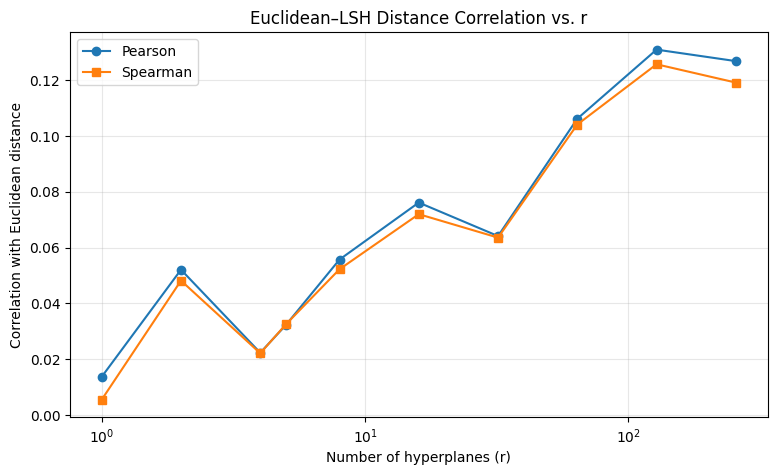

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    correlation_df["r"],
    correlation_df["pearson_normalized_hamming"],
    marker="o",
    label="Pearson"
)

plt.plot(
    correlation_df["r"],
    correlation_df["spearman_normalized_hamming"],
    marker="s",
    label="Spearman"
)

plt.xscale("symlog", linthresh=1)

plt.xlabel("Number of hyperplanes (r)")
plt.ylabel("Correlation with Euclidean distance")
plt.title(
    "Euclidean–LSH Distance Correlation vs. r"
)

plt.grid(True, alpha=0.3)
plt.legend()

main_figure_path = FIGURES_DIR / "correlation_vs_r.png"
plt.savefig(main_figure_path, dpi=300, bbox_inches="tight")
print("Saved:", main_figure_path)

plt.show()

## 15. Pairwise scatter plots

Scatter plots for representative values of $r$ visualize the relationship between Euclidean distance and Hamming distance.


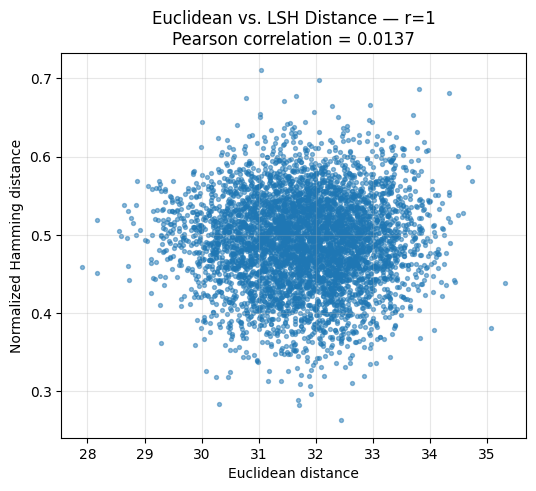

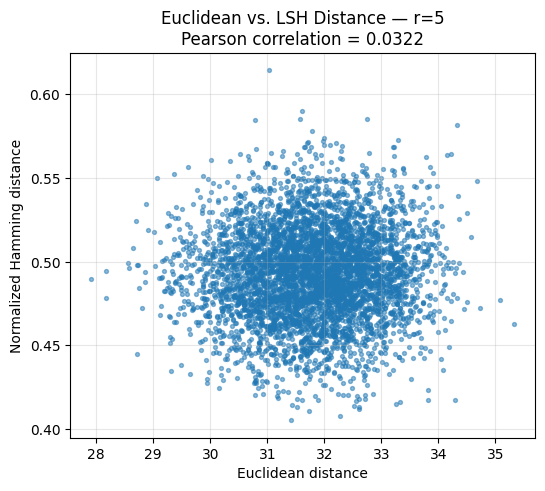

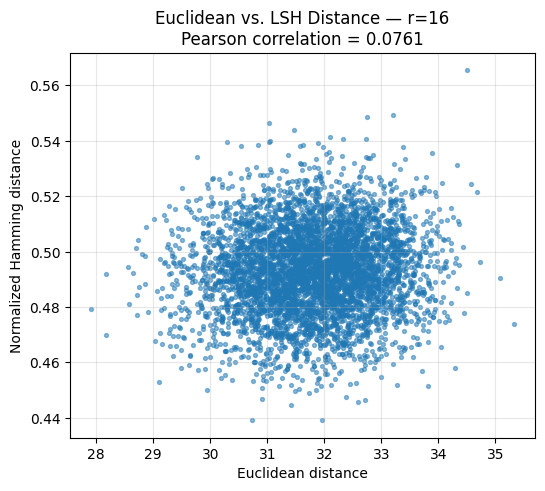

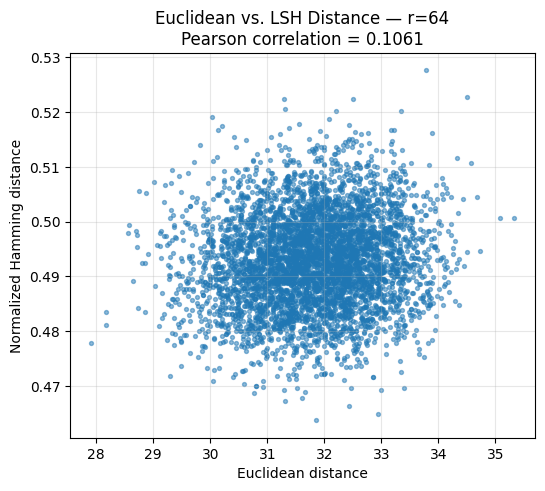

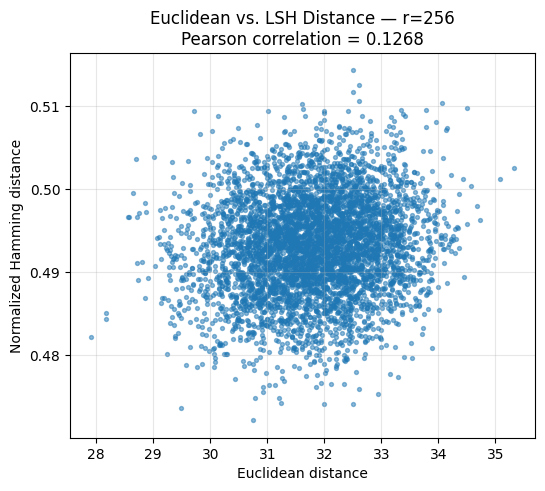

In [ ]:
SELECTED_R = [1, 5, 16, 64, 256]

for r in SELECTED_R:

    normalized = hamming_results[r]["normalized"]

    corr = correlation_df.loc[
        correlation_df["r"] == r,
        "pearson_normalized_hamming"
    ].iloc[0]

    plt.figure(figsize=(6, 5))

    plt.scatter(
        euclidean_distances,
        normalized,
        s=8,
        alpha=0.5
    )

    plt.xlabel("Euclidean distance")
    plt.ylabel("Normalized Hamming distance")

    plt.title(
        f"Euclidean vs. LSH Distance — r={r}\n"
        f"Pearson correlation = {corr:.4f}"
    )

    plt.grid(True, alpha=0.3)

    scatter_path = FIGURES_DIR / f"euclidean_vs_lsh_r{r}.png"
    plt.savefig(scatter_path, dpi=300, bbox_inches="tight")
    print("Saved:", scatter_path)

    plt.show()

## 16. Save summary results

The per-$r$ correlation table is saved as a CSV for direct inspection without rerunning the notebook.


In [ ]:
correlation_results_path = RESULTS_DIR / "correlation_results.csv"

correlation_df.to_csv(
    correlation_results_path,
    index=False
)

print("Saved:", correlation_results_path)


## 17. Save pairwise distances

The full table of Euclidean and Hamming distances for all 4,950 gradient pairs is saved as a CSV.


In [ ]:
pairwise_df = pd.DataFrame({
    "euclidean_distance": euclidean_distances
})

for r in R_VALUES:
    pairwise_df[f"hamming_raw_r{r}"] = hamming_results[r]["raw"]
    pairwise_df[f"hamming_normalized_r{r}"] = hamming_results[r]["normalized"]

pairwise_results_path = RESULTS_DIR / "pairwise_distances.csv"
pairwise_df.to_csv(
    pairwise_results_path,
    index=False
)

print("Saved:", pairwise_results_path)


## Instructions for reproducing the experiment

Run the notebook from top to bottom in a Python/Jupyter environment with numpy, pandas, matplotlib, scipy, torch, and torchvision installed.
The generated files are written to:

- results/correlation_results.csv
- results/pairwise_distances.csv
- results/figures/correlation_vs_r.png
- results/figures/euclidean_vs_lsh_r*.png

### Reference implementation

The hashing logic in this notebook is a local reproduction of the relevant functions from the public LSHFed reference implementation (`HaftzK/LSHFed`), so the repository itself is not required at runtime.

